In [1]:

import numpy as np
from generate_price_data import *
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product
from constructing_models import *

C:\Users\tobia\AppData\Roaming\Python\Python311\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\tobia\AppData\Roaming\Python\Python311\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\tobia\AppData\Roaming\Python\Python311\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please 

This part is the exact same as the simple DQN notebook (just constructing initial parameters and generating data)

87
color green: low vol
color yellow: medium vol
color red: high vol


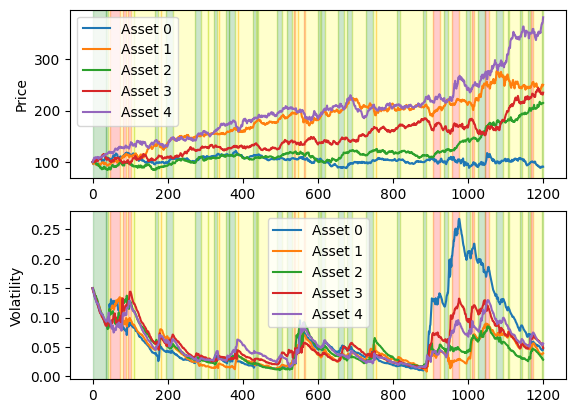

In [2]:
a = 5 # size of action space
n = 5 # num asssets

# shape (n, a)
A = np.random.dirichlet(np.full(n, 1), a)


m = 3 # action space
M = np.array([
    [0.95, 0.05, 0.00],
    [0.06, 0.91, 0.03],
    [0.00, 0.12, 0.88]
])

init_regime_prob_dist = [0.7, 0.15, 0.15]

T = 1000
T_test = 200

regime = np.random.choice(range(m), p=init_regime_prob_dist)
true_regimes_total = np.empty(T + T_test, dtype=int)
true_regimes_total[0] = regime
for t in range(1, T + T_test):
    next_regime = np.random.choice(range(m), p=M[regime, :])
    true_regimes_total[t] = next_regime
    regime = next_regime


price_data_total = np.empty((T + T_test, n))
volatility_data_total = np.empty((T + T_test, n))

xi_values = [0.05, 0.2, 0.6] # volatility of volatility
kappa_values = [6, 1.0, 0.5] # mean reversion rate
theta_values = [0.01, 0.2, 1.2] # mean volatility
mu_values = [0.0, 1.0, -1.0] # price drift

V0 = np.full(n, 0.15)
S0 = np.full(n, 100)

price_data_total = np.empty((T + T_test, n))
volatility_data_total = np.empty((T + T_test, n))

fig, (ax1, ax2) = plt.subplots(2)

x_breakpoints = []
x_breakpoints_labels = []

t = 0
while t < T + T_test:
    this_regime = true_regimes_total[t]
    tt = t + 1
    while tt < T + T_test:
        if true_regimes_total[tt] == this_regime:
            tt += 1
        else:
            break
    x_breakpoints.append(tt)
    x_breakpoints_labels.append(this_regime)
    volatility_data_total[t:tt, :] = np.array([
            generate_volatility(
                V0=V0[i],
                xi=xi_values[this_regime],
                theta=theta_values[this_regime],
                kappa=kappa_values[this_regime],
                N=tt - t,
                dt=1/365
            )
            for i in range(n)
        ]).T
    price_data_total[t:tt, :] = np.array([
        generate_prices(
            vola_values=volatility_data_total[t:tt, i],
            S0=S0[i],
            N=tt - t,
            mu=mu_values[this_regime],
            dt=1/365
    )
        for i in range(n)
    ]).T
    V0 = volatility_data_total[tt - 1, :]
    S0 = price_data_total[tt - 1, :]
    t = tt

x_breakpoints_labels.append(this_regime)
x_breakpoints.append(t)

price_data = price_data_total[:T]
price_data_eval = price_data_total[T:]
volatility_data = volatility_data_total[:T]
volatility_data_data_eval = volatility_data_total[T:]

for i in range(a):
    ax1.plot(range(T + T_test), price_data_total[:, i], label=f"Asset {i}")
    ax2.plot(range(T + T_test), volatility_data_total[:, i], label=f"Asset {i}")

ax1.legend()
ax2.legend()
ax1.set_ylabel("Price")
ax2.set_ylabel("Volatility")

colors = ["green", "yellow", "red"]
color_labels = ["low vol", "medium vol", "high vol"]

for i in range(len(x_breakpoints) - 1):
    ax1.axvspan(x_breakpoints[i],
                x_breakpoints[i + 1], color=colors[x_breakpoints_labels[i]],
                alpha=0.2)
    ax2.axvspan(x_breakpoints[i],
                x_breakpoints[i + 1], color=colors[x_breakpoints_labels[i]],
                alpha=0.2)

true_regimes = true_regimes_total[:T]
true_regimes_eval = true_regimes_total[T:]

ax1.axvspan(0, x_breakpoints[0], color=colors[true_regimes[0]], alpha=0.2)
ax2.axvspan(0, x_breakpoints[0], color=colors[true_regimes[0]], alpha=0.2)

print(len(x_breakpoints_labels))

for c, cl in zip(colors, color_labels):
    print(f"color {c}: {cl}")

plt.show()

Compute returns from raw price series

In [3]:
total_returns = pd.DataFrame(price_data_total).pct_change(axis=0).to_numpy()
returns_train = total_returns[:T]
returns_train[0, :] = np.zeros(n)

# construct returns and volatility data 
vola_lookback = 15
mean_returns = np.mean(returns_train, axis=1)
vola = pd.Series(mean_returns).rolling(vola_lookback, min_periods=1).std().values
vola[0] = 0

print('shape total returns:', total_returns.shape)
print('returns train shape:', returns_train.shape)

shape total returns: (1200, 5)
returns train shape: (1000, 5)


We now construct a Tester instance to test different models.

The models are defined by the cartesian product of all parameter combinations. As an example, here we construct 3 models (because we have 3 model constructor functions).

### General procedure

The general procedure for the training of the model will be a bit different from the previous implementation, described in simple\_dqn.ipynb.

Instead of having one DQN model instance, we have two: one main model and one "target" model.

In [4]:
rb_capacity = [200] # capacity of buffer
rb_sample_size = [8] # sample N amount of instances from buffer
gamma = [0.95] # discount factor (used in Bellman equation)
t_replay_buffer = [100] # time after which we sampel from replay buffer
training_lookback_period = [15] # lookback period when training NN (# of timesteps)
model_constructors = [construct_dqn_1, construct_dqn_2, construct_dqn_3]
model_constructor_names = ["construct_dqn_1", "construct_dqn_2", "construct_dqn_3"]
target_update_freq = [50] # frequency of updating main network
action_space = [A]
state_space = [returns_train]
epsilon_decays = [0.99]

product_args = list(product(
    state_space, rb_capacity, rb_sample_size, action_space, gamma,
    target_update_freq, training_lookback_period, t_replay_buffer, model_constructors,
    epsilon_decays
    ))
for i, args in enumerate(product_args):
    ss, rbcap, rbss, asp, gam, targup, traininglookback, t_replay, mc, epsc = args
    model_constr_name = model_constructors.index(mc)
    model = Model2(
        ss, rbcap, rbss, asp, gam, targup, traininglookback, t_replay, mc, epsc, model_constr_name
        )
    model.train()
    print('Model trained')
    model.save(Path.cwd() / "producedModels" / "withTargetNetwork", f"model_{i}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━

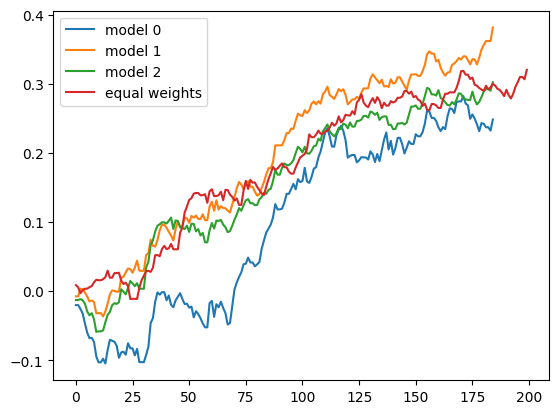

               mean return    sharpe   sortino
model 0           0.001254  1.925278  3.489607
model 1           0.001771  4.240670  8.486539
model 2           0.001451  3.499301  6.084327
equal weights     0.001409  3.676929  6.944399


In [4]:
returns_test = total_returns[T:] # (200, 5)
deployers = [
    ModelDeployer(
    modelpath=Path.cwd() / "producedModels" / "withTargetNetwork" / f"model_{i}.keras",
    data=returns_test,
    action_space=A
    )
    for i in range(3)
]

table = np.empty((len(deployers) + 1, 3))

for i, d in enumerate(deployers):
    (
        returns,
        cum_return,
        returns_vola_ann,
        sharpe,
        sortino,
        returns_equal_weights,
        returns_equal_weight_cum
    ) = d.run()
    table[i, :] = [np.mean(returns), sharpe, sortino]
    plt.plot(cum_return, label=f"model {i}")

sharpe_eq_weights = np.mean(returns_equal_weights) / np.std(returns_equal_weights) * np.sqrt(255)
sortino_eq_weights = np.mean(returns_equal_weights) / np.std(returns_equal_weights[returns_equal_weights < 0]) * np.sqrt(255)
table[-1, :] = [np.mean(returns_equal_weights), sharpe_eq_weights, sortino_eq_weights]
table = pd.DataFrame(table, index=[f"model {i}" for i in range(3)] + ["equal weights"], columns=["mean return", "sharpe", "sortino"])

plt.plot(returns_equal_weight_cum, label="equal weights")
plt.legend()
plt.show()

print(table)


